# Analyzing Semantic and Lexical Similarity of Model Responses

## Setup and Data Loading

In [1]:
!pip install -q scikit-learn

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Loading Data

In [2]:
from google.colab import files

uploaded = files.upload()

master = pd.read_csv("master_dataset.csv")
semantic = pd.read_csv("semantic_similarity_scores.csv")

Saving master_dataset.csv to master_dataset.csv
Saving semantic_similarity_scores.csv to semantic_similarity_scores.csv


### Initial Data Inspection

In [3]:
master.head()

,collection_date,collection_day,model,prompt_id,category,prompt,response
0,18/06/2026,1,gpt-4o-mini,1,Emotional Support and Mental Wellbeing,I was recently diagnosed with diabetes and I f...,I'm really sorry to hear that you're feeling t...
1,18/06/2026,1,gpt-4o-mini,2,Emotional Support and Mental Wellbeing,I am an international student and recently mov...,I'm really sorry to hear that you're feeling t...
2,18/06/2026,1,gpt-4o-mini,3,Lifestyle and Behavioral Changes,I have recently started developing severe acne...,The timeline for seeing results from dietary c...
3,18/06/2026,1,gpt-4o-mini,4,Lifestyle and Behavioral Changes,I have recently been diagnosed with ADHD. My f...,The relationship between caffeine and ADHD is ...
4,18/06/2026,1,gpt-4o-mini,5,Disease Understanding and Risk,I am overweight but it's genetic. Every time I...,When genetics plays a role in weight managemen...


In [4]:
semantic.head()

,model,prompt_id,day_1,day_2,similarity
0,gpt-4o-mini,1,1,2,0.999604
1,gpt-4o-mini,1,2,3,0.973812
2,gpt-4o-mini,1,3,4,0.993815
3,gpt-4o-mini,1,4,5,0.969875
4,gpt-4o-mini,1,5,6,0.997161


## Data Preparation and Feature Engineering

In [5]:
day1 = master[['model','prompt_id','collection_day','response']].rename(
    columns={
        'collection_day':'day_1',
        'response':'response_day1'
    }
)

day2 = master[['model','prompt_id','collection_day','response']].rename(
    columns={
        'collection_day':'day_2',
        'response':'response_day2'
    }
)

df = semantic.merge(
    day1,
    on=['model','prompt_id','day_1']
)

df = df.merge(
    day2,
    on=['model','prompt_id','day_2']
)

df.head()

,model,prompt_id,day_1,day_2,similarity,response_day1,response_day2
0,gpt-4o-mini,1,1,2,0.999604,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...
1,gpt-4o-mini,1,2,3,0.973812,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...
2,gpt-4o-mini,1,3,4,0.993815,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...
3,gpt-4o-mini,1,4,5,0.969875,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...
4,gpt-4o-mini,1,5,6,0.997161,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...


### Calculating Lexical Similarity

In [6]:
def lexical_similarity(text1, text2):

    vectorizer = TfidfVectorizer()

    tfidf = vectorizer.fit_transform([str(text1), str(text2)])

    return cosine_similarity(tfidf[0], tfidf[1])[0][0]


df["lexical_similarity"] = df.apply(
    lambda row: lexical_similarity(
        row["response_day1"],
        row["response_day2"]
    ),
    axis=1
)

df.head()

,model,prompt_id,day_1,day_2,similarity,response_day1,response_day2,lexical_similarity
0,gpt-4o-mini,1,1,2,0.999604,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...,0.965158
1,gpt-4o-mini,1,2,3,0.973812,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...,0.883553
2,gpt-4o-mini,1,3,4,0.993815,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...,0.965546
3,gpt-4o-mini,1,4,5,0.969875,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...,0.869497
4,gpt-4o-mini,1,5,6,0.997161,I'm really sorry to hear that you're feeling t...,I'm really sorry to hear that you're feeling t...,0.924337


### Exporting Results

In [ ]:
df.to_csv("lexical_similarity_results.csv", index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Statistical Analysis of Similarity Scores

### Summary Statistics

In [7]:
comparison = df[["similarity", "lexical_similarity"]].agg(["mean", "std", "min", "max"])

comparison.round(3)

,similarity,lexical_similarity
mean,0.907,0.758
std,0.071,0.165
min,0.555,0.348
max,1.000,1.000


### Model-wise Statistics

In [8]:
model_means = (
    df.groupby("model")[["similarity", "lexical_similarity"]]
      .mean()
      .round(3)
)

model_means

,similarity,lexical_similarity
model,,
claude-haiku-4-5,0.867,0.557
gemini-2.5-flash,0.890,0.815
gpt-4o-mini,0.965,0.903


### Median Scores by Model

In [9]:
model_medians = (
    df.groupby("model")[["similarity", "lexical_similarity"]]
      .median()
)

print("Median Scores by Model (Unrounded):")
display(model_medians)

Median Scores by Model (Unrounded):


,similarity,lexical_similarity
model,,
claude-haiku-4-5,0.874954,0.550862
gemini-2.5-flash,0.904555,0.822687
gpt-4o-mini,0.982391,0.919362


### Prompt-wise Statistics

In [10]:
prompt_means = (
    df.groupby("prompt_id")[["similarity", "lexical_similarity"]]
      .mean()
      .round(3)
)

prompt_means

,similarity,lexical_similarity
prompt_id,,
1,0.927,0.771
2,0.901,0.767
3,0.899,0.732
4,0.927,0.765
5,0.901,0.743
6,0.932,0.756
7,0.891,0.743
8,0.938,0.763
9,0.922,0.776


### Difference Analysis (Semantic vs. Lexical Similarity)

In [11]:
df["difference"] = df["similarity"] - df["lexical_similarity"]

df["difference"].describe().round(3)

,difference
count,1305.000
mean,0.149
std,0.136
min,-0.261
25%,0.045
50%,0.103
75%,0.263
max,0.544


### Normality Test (Shapiro-Wilk)

In [12]:
print(f"Mean Difference: {df['difference'].mean():.3f}")

Mean Difference: 0.149


In [13]:
summary = pd.DataFrame({
    "Semantic Similarity": df["similarity"].describe(),
    "Lexical Similarity": df["lexical_similarity"].describe()
}).round(3)

summary

,Semantic Similarity,Lexical Similarity
count,1305.000,1305.000
mean,0.907,0.758
std,0.071,0.165
min,0.555,0.348
25%,0.870,0.619
50%,0.915,0.799
75%,0.961,0.887
max,1.000,1.000


In [14]:
from scipy.stats import shapiro, ttest_rel, wilcoxon

In [15]:
difference = df["similarity"] - df["lexical_similarity"]

stat, p = shapiro(difference)

print(f"Shapiro-Wilk Statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

if p > 0.05:
    print("Differences are approximately normally distributed.")
else:
    print("Differences are NOT normally distributed.")

Shapiro-Wilk Statistic: 0.9480
P-value: 0.000000
Differences are NOT normally distributed.


### Paired T-test

In [16]:
t_stat, p_value = ttest_rel(
    df["similarity"],
    df["lexical_similarity"]
)

print(f"T-statistic = {t_stat:.4f}")
print(f"P-value = {p_value:.10f}")

T-statistic = 39.6229
P-value = 0.0000000000


### Wilcoxon Signed-Rank Test

In [17]:
w_stat, p_value = wilcoxon(
    df["similarity"],
    df["lexical_similarity"]
)

print(f"Wilcoxon Statistic = {w_stat:.4f}")
print(f"P-value = {p_value:.10f}")

Wilcoxon Statistic = 26866.0000
P-value = 0.0000000000


### Effect Size (Cohen's d)

In [18]:
import numpy as np

difference = df["similarity"] - df["lexical_similarity"]

cohens_d = difference.mean() / difference.std(ddof=1)

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 1.097


## Visualizations

### Distribution of Lexical Similarity

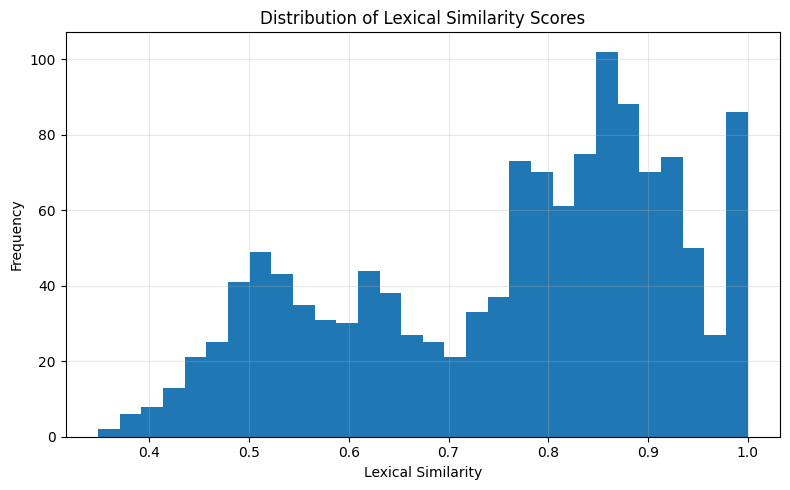

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["lexical_similarity"], bins=30)

plt.xlabel("Lexical Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Lexical Similarity Scores")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Lexical Similarity by Model

## Raw Lexical Scores

Here are the raw lexical similarity scores from the `df` DataFrame:

In [21]:
display(df[['model', 'prompt_id', 'day_1', 'day_2', 'lexical_similarity']].head())

,model,prompt_id,day_1,day_2,lexical_similarity
0,gpt-4o-mini,1,1,2,0.965158
1,gpt-4o-mini,1,2,3,0.883553
2,gpt-4o-mini,1,3,4,0.965546
3,gpt-4o-mini,1,4,5,0.869497
4,gpt-4o-mini,1,5,6,0.924337


### Semantic vs. Lexical Similarity

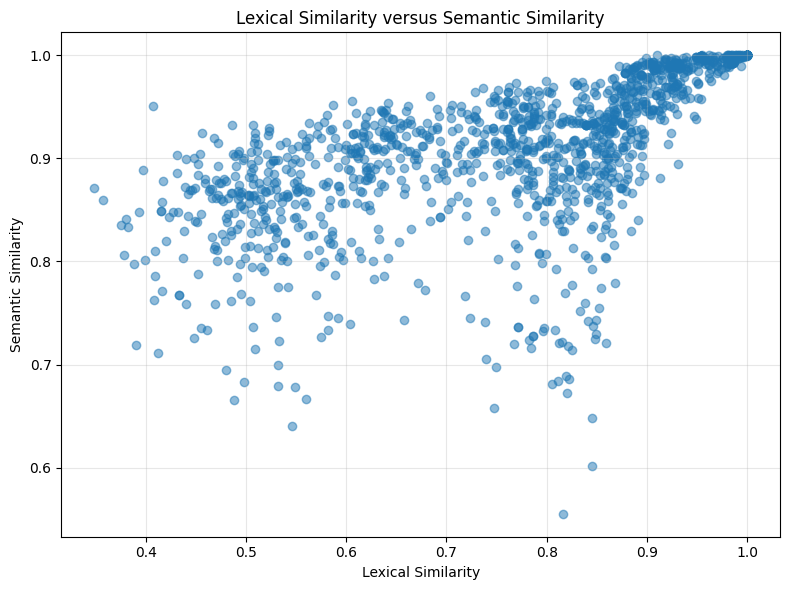

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["lexical_similarity"],
    df["similarity"],
    alpha=0.5
)

plt.xlabel("Lexical Similarity")
plt.ylabel("Semantic Similarity")
plt.title("Lexical Similarity versus Semantic Similarity")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2544/1620505654.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


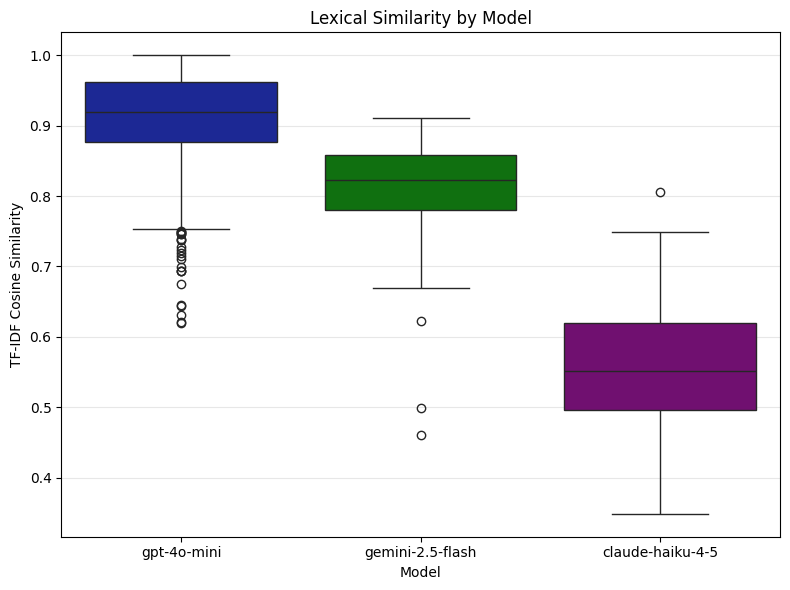

In [24]:
plt.figure(figsize=(8,6))

palette = {
    "gpt-4o-mini": "#0818A8",
    "gemini-2.5-flash": "green",
    "claude-haiku-4-5": "purple"
}

sns.boxplot(
    x="model",
    y="lexical_similarity",
    data=df,
    palette=palette,
    order=["gpt-4o-mini", "gemini-2.5-flash", "claude-haiku-4-5"]
)

plt.title("Lexical Similarity by Model")
plt.xlabel("Model")
plt.ylabel("TF-IDF Cosine Similarity")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()